<a href="https://colab.research.google.com/github/Medrodi/MIIGAIK-Computer-Math/blob/main/6.%20%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%20%D1%81%20%D1%8D%D0%BB%D0%B5%D0%BA%D1%82%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8%20%D1%82%D0%B0%D0%B1%D0%BB%D0%B8%D1%86%D0%B0%D0%BC%D0%B8.%20%D0%9C%D0%BD%D0%BE%D0%B3%D0%BE%D0%BF%D0%BE%D1%82%D0%BE%D1%87%D0%BD%D0%B0%D1%8F%20%D0%B8%20%D0%BC%D0%BD%D0%BE%D0%B3%D0%BE%D0%BF%D1%80%D0%BE%D1%86%D0%B5%D1%81%D1%81%D0%BE%D1%80%D0%BD%D0%B0%D1%8F%20%D0%BE%D0%BF%D1%82%D0%B8%D0%BC%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%82%D0%BE%D1%80%D1%8B%20/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%A4%D0%BE%D1%80%D0%BC%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%8D%D0%BB%D0%B5%D0%BA%D1%82%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%82%D0%B0%D0%B1%D0%BB%D0%B8%D1%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №6. Формирование электронных таблиц. Многопоточная и многопроцессорная оптимизация. Работа с генераторами

# Теоретическая часть

## 1. Генераторы в Python

**Генератор данных** - это специальный вид функции в Python, который позволяет создавать последовательность значений по мере необходимости. Вместо того чтобы сразу генерировать и хранить все значения, генератор создает их по одному по требованию.


1. **Создание генератора:**
    - Генератор создается с использованием ключевого слова `yield` внутри функции.
    - Вместо `return`, генератор использует `yield` для возврата значения и приостановки выполнения функции.
    - Пример:
        ```python
        def my_generator():
            yield 1
            yield 2
            yield 3

        gen = my_generator()
        ```

2. **Ленивая загрузка:**
    - Генераторы работают с ленивой загрузкой (lazy evaluation).
    - Они не создают все значения сразу, а только по мере запроса.
    - Это полезно для обработки больших объемов данных, когда нельзя или не нужно хранить все значения в памяти.

3. **Итерация по генератору:**
    - Генераторы можно использовать в циклах `for`.
    - Каждый вызов `yield` возвращает следующее значение из генератора.
    - Пример:
        ```python
        for value in gen:
            print(value)
        ```

4. **Состояние генератора:**
    - Генераторы сохраняют свое состояние между вызовами.
    - После каждого `yield` выполнение функции приостанавливается, а состояние сохраняется.
    - При следующем вызове генератор продолжает выполнение с того места, где остановился.

5. **Применение генераторов:**
    - Генераторы полезны для обработки больших файлов, потоковых данных, бесконечных последовательностей и других сценариев, где требуется эффективная загрузка данных.

### 1.1. **Функция `next()`**

1. **Функция `next()`**:
    - `next()` - это встроенная функция Python, которая используется для получения следующего значения из итератора (включая генераторы).
    - Когда вызывается `next()`, итератор продвигается к следующему элементу и возвращает его.
    - Если больше элементов нет, вызывается исключение `StopIteration`.

2. **Использование в генераторах**:
    - В примерах, которые я предоставил ранее, мы использовали `next()` для получения следующей порции данных из генератора.
    - В генераторах `next()` используется для получения следующего значения, которое было создано с помощью `yield`.
    - Пример:
        ```python
        def my_generator():
            yield 1
            yield 2
            yield 3

        gen = my_generator()

        print(next(gen))  # Выведет 1
        print(next(gen))  # Выведет 2
        print(next(gen))  # Выведет 3
        ```

3. **Обработка исключения `StopIteration`**:
    - Если больше элементов нет, вызывается исключение `StopIteration`.
    - Поэтому важно использовать `next()` внутри блока `try`/`except` для обработки этого исключения.

В общем, `next()` -  позволяет нам получать значения по мере необходимости, что особенно полезно при обработке больших объемов данных.

### 1.2. Примеры генераторов:



1. **Генератор случайных чисел:**
    - Этот генератор возвращает случайные числа в заданном диапазоне.

In [ ]:
import random

def random_numbers(n, min_val, max_val):
    for _ in range(n):
        yield random.randint(min_val, max_val)

In [ ]:
# Пример использования

gen = random_numbers(5, 1, 10)

for num in gen:
    print(num)

9
10
7
1
1


In [ ]:
gen = random_numbers(5, 1, 10)

In [ ]:
next(gen)

2

2. **Генератор бесконечной последовательности чисел:**
    - Этот формирует создает бесконечную последовательность чисел, начиная с заданного значения.


In [ ]:
def infinite_sequence(start=0):
    while True:
        yield start
        start += 1

In [ ]:
# Пример использования
numbers = infinite_sequence(10)
for _ in range(5):
    print(next(numbers))

10
11
12
13
14


In [ ]:
next(numbers)

15


3. **Генератор факториалов:**
    - Этот генератор создает последовательность факториалов чисел.


In [ ]:
def factorial():
    result = 1
    n = 1
    while True:
        yield result
        n += 1
        result *= n

In [ ]:
# Пример использования
fact_gen = factorial()
for _ in range(6):
    print(next(fact_gen))

1
2
6
24
120
720


4. **Генератор строк из файла:**
    - Этот генератор читает строки из текстового файла по одной.


In [ ]:
def generate_text_file(file_path="my_text_file.txt", num_lines=15):
    with open(file_path, 'w') as file:
        for i in range(1, num_lines + 1):
            file.write(f"This is line {i}\n")
generate_text_file()

def read_lines(file_path):
    with open(file_path, 'r') as file:
        for line in file:
            yield line.strip()

In [ ]:
# Пример использования
file_path = "my_text_file.txt"

gen = read_lines(file_path)

for line in gen:
    print(line)

This is line 1
This is line 2
This is line 3
This is line 4
This is line 5
This is line 6
This is line 7
This is line 8
This is line 9
This is line 10
This is line 11
This is line 12
This is line 13
This is line 14
This is line 15


In [ ]:
gen = read_lines(file_path)

In [ ]:
next(gen)

'This is line 1'

## 2. Оптимизация вычислений

Оптимизация программного обеспечения является важной частью разработки программного обеспечения. Она включает в себя ряд техник и подходов, направленных на улучшение производительности и эффективности программы. Одним из способов достижения этого является использование параллелизма, который может быть реализован с помощью процессов или потоков.


- **Процесс** - это программа, которая выполняется на вашем компьютере. Каждый процесс имеет свое собственное виртуальное пространство памяти и работает независимо от других процессов. Процессы могут взаимодействовать друг с другом через системные вызовы.

- **Поток**, с другой стороны, является частью процесса. Потоки в одном процессе могут делиться некоторыми ресурсами, такими как память, что делает их более легкими и быстрее в создании и переключении, чем процессы. Потоки в одном процессе могут работать параллельно, что позволяет более эффективно использовать многоядерные процессоры.



Можно сказать, что процесс - это как программа, выполняющаяся на вашем компьютере, а поток - это задача, которую выполняет этот процесс. Если у вас есть несколько потоков в одном процессе, они могут выполнять задачи параллельно.

В зависимости от конкретных требований и ограничений вашего приложения, вы можете выбрать использовать либо процессы, либо потоки для оптимизации вашей программы. Оба подхода имеют свои преимущества и недостатки, и выбор между ними будет зависеть от специфики вашей задачи.

### 2.1. Модули для управления процессами и потоками в Python

- **Multiprocessing** в Python - это модуль, который позволяет создавать процессы, используя API. Он обеспечивает как локальную, так и удаленную параллельность, эффективно обходя глобальную блокировку интерпретатора за счет использования подпроцессов вместо потоков. Это позволяет полностью использовать несколько ядер (процессоров) на данной машине. Он работает как на POSIX, так и на Windows.

- **ThreadPoolExecutor** в Python - это класс, который предоставляет возможность создания и использования пула потоков для эффективного выполнения задач параллельно. Этот класс является частью стандартной библиотеки Python и предлагает легко используемые пулы рабочих потоков посредством современного шаблона исполнителя. Он идеален для выполнения циклов задач ввода-вывода параллельно и для выдачи задач асинхронно.

> В обоих случаях, `multiprocessing` и `ThreadPoolExecutor` предоставляют удобные и эффективные способы для параллельного выполнения задач в Python. Они оба являются мощными инструментами, которые могут значительно улучшить производительность и эффективность ваших программ на Python. Однако выбор между ними зависит от конкретных требований и ограничений вашего приложения. В некоторых случаях может быть предпочтительнее использовать `multiprocessing`, в то время как в других случаях лучше использовать `ThreadPoolExecutor`.

#### *Таблица №1. Сравнительная таблица Multiprocessing и ThreadPoolExecutor*

| Критерий | Multiprocessing | ThreadPoolExecutor |
|---|---|---|
| **Тип** | **Процессы** | **Потоки** |
| **Совместное использование данных** | **Сериализация** | **Объекты Python** |
| **Скорость** | **Высокая** | **Средняя** |
| **Сложность** | **Высокая** | **Низкая** |
| **Ошибки** | **Ошибки сериализации** | **Ограничения потоков** |
| **Подходит для** | **Задачи, требующие много ресурсов** | **Задачи, не требующие много ресурсов** |


**Рекомендации:**

* **Используйте** Multiprocessing для задач, которые **можно** разделить на **независимые** части и **требуют** много ресурсов.
* **Используйте** ThreadPoolExecutor для задач, которые **не** требуют большого количества ресурсов и **не могут** быть разделены на независимые части.


### 2.2. Сериализация

**Сериализация** - это процесс преобразования объекта Python в байтовый поток, который можно сохранить или передать по сети. Это может быть полезно для сохранения данных, обмена данными между программами или для удаленного выполнения кода.

**Пример:**

```python
import pickle

a = [1, 2, 3]

with open("data.pkl", "wb") as f:
    pickle.dump(a, f)

with open("data.pkl", "rb") as f:
    b = pickle.load(f)

print(a == b)  # True
```

В этом примере мы сериализовали список `a` в файл `data.pkl`. Затем мы десериализовали файл обратно в переменную `b`.

#### Объекты Python

**Объекты Python** - это сущности, которые имеют состояние и поведение. Они могут быть созданы из классов или с помощью встроенных функций Python.

**Пример:**

```python
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

p = Person("John Doe", 30)

print(p.name)  # John Doe
print(p.age)  # 30
```

В этом примере мы создали класс `Person` и затем создали объект `p` этого класса.

#### Сериализация и объекты Python

* **Сериализация** может быть использована для совместного использования данных между процессами или машинами.
* **Объекты Python** могут быть сериализованы для сохранения их состояния или для передачи их по сети.



### 2.3. **Простыми словами:**

##### **2.3.1. Процессы и потоки:**



- **Процесс:**
  - Представьте себе **пекарню**. Пекарня – это **процесс**, в котором происходит выпечка хлеба. В пекарне есть разные **инструменты** (миксеры, печи) и **ингредиенты** (мука, вода), которые используются для создания **продукта** (хлеба).

- **Поток:**
  - Теперь представьте, что **пекари** – это **потоки** в пекарне. Каждый пекарь выполняет **часть** работы (замешивает тесто, ставит хлеб в печь), но все они **вместе**

**В чем разница?**
* **Процесс** – это **самостоятельная** программа, которая работает в **своей** памяти.
* **Поток** – это **часть** процесса, которая выполняется **одновременно** с другими потоками.




##### **2.3.2. Многопроцессорность и пул потоков:**

1. **Multiprocessing (Многопроцессорность)**:
    - Представьте, что у вас есть несколько "рабочих", каждый из которых выполняет свою задачу.
    - В многопроцессорном подходе каждый рабочий (процесс) работает в отдельном ядре (процессоре).
    - Это позволяет выполнять несколько задач одновременно, так как каждый процесс имеет свои собственные ресурсы (память, вычислительную мощность).
    - Пример: Если у вас есть 4 ядра на компьютере, вы можете запустить 4 процесса параллельно для ускорения вычислений.

2. **ThreadPoolExecutor (Пул потоков)**:
    - Представьте, что у вас есть команда рабочих, работающих в одной комнате.
    - В пуле потоков все рабочие (потоки) используют общие ресурсы (память, вычислительную мощность).
    - Они могут выполнять разные задачи, но в одном и том же ядре (процессоре).
    - Это позволяет эффективно использовать доступные ресурсы, но потоки работают последовательно (не одновременно).
    - Пример: Если у вас есть 4 ядра, но много задач, пул потоков поможет распределить работу между потоками.



>**Вывод**: Многопроцессорность позволяет выполнять задачи одновременно, но требует больше ресурсов. Пул потоков более эффективен в использовании ресурсов, но работает последовательно. Выбор зависит от конкретной задачи и доступных ресурсов.

### 2.4. Примеры

### 2.4.1. Пример №1

Ниже приведен пример кода на Python, который демонстрирует использование модулей `multiprocessing` и `ThreadPoolExecutor` для параллельного выполнения задачи. Задача, которую выполняет этот код, - это возведение в квадрат каждого числа в диапазоне от 0 до 100000:

1. В начале кода определяется функция `task`, которая принимает число и возвращает его квадрат. Затем определяется функция `measure_time`, которая измеряет время выполнения функции.

2. В основной части кода сначала выполняется последовательное выполнение задачи с использованием функции `map`. Затем та же задача выполняется параллельно с использованием модуля `multiprocessing`. Наконец, задача выполняется с использованием `ThreadPoolExecutor`.

3. Время выполнения каждого из этих подходов замеряется и выводится на экран. Это позволяет сравнить производительность каждого подхода.

In [ ]:
import multiprocessing
import time
import math
from concurrent.futures.thread import ThreadPoolExecutor


# def task(x):
#     return x ** 2

# def task(x):
#     with open("data.txt", "w+") as f:
#         data = f.read()
#     result = x ** 2 + len(data)
#     return result

def task(x):
    if x % 11 == 0:
        time.sleep(0.0001)  # Имитация более длительной задачи
    return x ** 2


def measure_time(func, args):
    start = time.time()
    result = func(*args)
    end = time.time()
    return end - start

num_processes = multiprocessing.cpu_count()

if __name__ == '__main__':
    # Sequential execution (no multiprocessing or ThreadPoolExecutor)
    sequential_time = measure_time(list, [map(task, range(100000))])
    print(f"Sequential execution time: {sequential_time:.4f} seconds")

    # multiprocessing
    with multiprocessing.Pool(processes=num_processes) as pool:
        multiprocessing_time = measure_time(pool.map, [task, range(100000)])
    print(f"Multiprocessing time: {multiprocessing_time:.4f} seconds")

    # ThreadPoolExecutor
    with ThreadPoolExecutor() as executor:
        threadpoolexecutor_time = measure_time(executor.map, [task, range(100000)])
    print(f"ThreadPoolExecutor time: {threadpoolexecutor_time:.4f} seconds")

Sequential execution time: 2.0021 seconds
Multiprocessing time: 1.1158 seconds
ThreadPoolExecutor time: 3.0516 seconds


### 2.4.2. Пример №2

Следующий пример кода на Python демонстрирует использование модулей `multiprocessing` и `ThreadPoolExecutor` для параллельного вычисления геодезического расстояния между парами точек, представленных в DataFrame.

1. В начале кода определяется функция `generate_random_dataframe`, которая генерирует DataFrame с указанным количеством случайных значений для широты и долготы. Затем создается DataFrame с 100 случайными точками.
2. Функция `calculate_distance` вычисляет геодезическое расстояние между двумя точками, используя библиотеку `geopy`.
3. Затем определены три функции для вычисления расстояний между всеми парами точек: `parallel_distance_calculation`, `parallel_distance_calculation_multiprocessing` и `parallel_distance_calculation_threadpool`. Первая функция вычисляет расстояния последовательно, вторая использует `multiprocessing` для параллельного вычисления, а третья использует `ThreadPoolExecutor`.
4. В конце кода измеряется время выполнения каждого из этих подходов и выводится на экран. Это позволяет сравнить производительность каждого подхода.

In [ ]:
import pandas as pd
from geopy.distance import geodesic
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import time


# Предположим, у нас есть DataFrame с GPS-координатами
def generate_random_dataframe(num_values, lat_range=(30, 60), lon_range=(-130, 130)):
    """
    Генерирует датафрейм с указанным количеством случайных значений для широты и долготы.

    :param num_values: Количество значений
    :param lat_range: Диапазон для широты (по умолчанию от 30 до 60)
    :param lon_range: Диапазон для долготы (по умолчанию от -130 до 130)
    :return: Датафрейм с случайными значениями
    """
    latitudes = np.random.uniform(low=lat_range[0], high=lat_range[1], size=num_values)
    longitudes = np.random.uniform(low=lon_range[0], high=lon_range[1], size=num_values)

    df = pd.DataFrame({
        'id': range(1, num_values + 1),
        'lat': latitudes,
        'lon': longitudes
    })

    return df

# Формируем DataFrame
df = generate_random_dataframe(100)


# Функция для вычисления расстояния между двумя точками
def calculate_distance(pair):
    idx1, idx2 = pair
    coord1 = (df.at[idx1, 'lat'], df.at[idx1, 'lon'])
    coord2 = (df.at[idx2, 'lat'], df.at[idx2, 'lon'])
    return geodesic(coord1, coord2).kilometers


# Вычисление без оптимизации
def parallel_distance_calculation(df):
    pairs = [(i, j) for i in df.index for j in df.index if i < j]
    distances = []
    for pair in pairs:
        distances.append(calculate_distance(pair))
    return distances, pairs


# Функция для параллельного вычисления, используя multiprocessing
def parallel_distance_calculation_multiprocessing(df):
    pairs = [(i, j) for i in df.index for j in df.index if i < j]
    pool = mp.Pool(processes=mp.cpu_count())
    distances = pool.map(calculate_distance, pairs)
    pool.close()
    pool.join()
    return distances, pairs


# Функция для параллельного вычисления, используя ThreadPoolExecutor
def parallel_distance_calculation_threadpool(df):
    pairs = [(i, j) for i in df.index for j in df.index if i < j]
    with ThreadPoolExecutor() as executor:
        distances = list(executor.map(calculate_distance, pairs))
    return distances, pairs

In [ ]:
if __name__ == "__main__":

    # Измеряем время без оптимизации
    start_time = time.time()
    distances_multiprocessing, _ = parallel_distance_calculation(df)
    end_time = time.time()
    print(f"Время выполнения без оптимизации: {end_time - start_time:.4f} секунд")

    # Измеряем время c multiprocessing
    start_time = time.time()
    distances_multiprocessing, _ = parallel_distance_calculation_multiprocessing(df)
    end_time = time.time()
    print(f"Время выполнения c multiprocessing: {end_time - start_time:.4f} секунд")

    # Измеряем время выполнения с ThreadPoolExecutor
    start_time = time.time()
    distances_threadpool, _ = parallel_distance_calculation_threadpool(df)
    end_time = time.time()
    print(f"Время выполнения с ThreadPoolExecutor: {end_time - start_time:.4f} секунд")

    # # Вызов функции и получение `pairs`
    # distances, pairs = parallel_distance_calculation(df)

    # # Вывод результатов
    # for pair, distance in zip(pairs, distances):
    #     print(f"Расстояние между точками {pair[0]} и {pair[1]}: {distance:.2f} км")

Время выполнения без оптимизации: 0.7552 секунд
Время выполнения c multiprocessing: 0.6808 секунд
Время выполнения с ThreadPoolExecutor: 0.8708 секунд


**Время выполнения вычислений для 1000 точек на процессоре Intel Xeon e5 2678v3 (12 ядер/24 потока):**

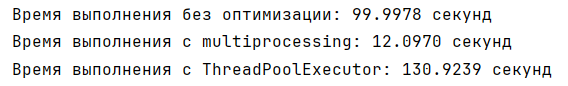

### 2.4.1. Пример №3 (Дополнительный)

Вспомним оптимизацию вычислений используя cupu:

In [ ]:
import time
import numpy as np

# Попытка импортировать cupy
try:
    import cupy as cp
    use_cuda = cp.is_available()
except ImportError:
    use_cuda = False

# use_cuda = False

def process_on_cpu(data):
    # Умножение матриц на CPU с использованием numpy
    return np.dot(data, data)

def process_on_gpu(data):
    # Умножение матриц на GPU с использованием cupy
    data_gpu = cp.asarray(data)
    result_gpu = cp.dot(data_gpu, data_gpu)
    return cp.asnumpy(result_gpu)

# Функция для замера времени выполнения
def measure_time(func, data):
    start_time = time.time()
    result = func(data)
    end_time = time.time()
    print(f"Время выполнения {func.__name__}: {end_time - start_time} секунд")
    # return result

# Данные для обработки
data = np.random.rand(1000, 1000)

# Выбор функции обработки в зависимости от доступности CUDA
if use_cuda:
    print("CUDA доступна. Используем GPU для обработки.")
    process_data = process_on_gpu
else:
    print("CUDA не доступна. Используем CPU для обработки.")
    process_data = process_on_cpu

# Замер скорости выполнения
measure_time(process_data, data)

CUDA доступна. Используем GPU для обработки.
Время выполнения process_on_gpu: 0.3578815460205078 секунд


# Практическая часть

Реализуем эффективное программное решение прямой геодезической задачи

- Входные данные:
  - csv-файл с параметрами (Xa, Ya, d, alpha)

- Выходные данные (опционально):
  - csv-файл с вычесленными параметрами (dX, dY, Xb, Yb)
  - xlsx-файл с вычесленными параметрами (dX, dY, Xb, Yb)
  - DataFrame с вычесленными параметрами (dX, dY, Xb, Yb)


## 1. Генератор синтетического набора входных данных

In [ ]:
import random
import csv
import numpy as np
from openpyxl import Workbook

def generate_data(filename, num_files=1, num_records_range=(100, 200),
                  Xa_range=(1100, 10000), Ya_range=(1100, 10000),
                  d_range=(1, 1500), alpha_range=(1, 360), save_xlsx=False):

    for i in range(num_files):
        num_records = random.randint(*num_records_range)

        # Создание массивов NumPy
        Xa = np.random.uniform(*Xa_range, size=num_records)
        Ya = np.random.uniform(*Ya_range, size=num_records)
        d = np.random.uniform(*d_range, size=num_records)
        alpha = np.random.uniform(*alpha_range, size=num_records)

        data = np.column_stack((Xa, Ya, d, alpha))

        file_extension = ".csv" # По умолчанию сохраняем в формате CSV
        if save_xlsx:
            file_extension = ".xlsx" # Если указано сохранение в XLSX

        if i > 0:
            full_filename = f"{filename}_{i}{file_extension}" # Добавляем индекс к имени файла
        else:
            full_filename = f"{filename}{file_extension}"

        if save_xlsx:
            wb = Workbook()
            ws = wb.active
            ws.append(["Xa", "Ya", "d", "alpha"])
            ws.append(data)
            wb.save(full_filename)
        else:
            with open(full_filename, 'w', newline='') as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(["Xa", "Ya", "d", "alpha"])
                writer.writerows(data)

        print(f"Данные сгенерированы и сохранены в {full_filename}")

In [ ]:
generate_data("big_data", num_files=1, num_records_range=(10000000, 15000000))
generate_data("my_data", num_files=5, num_records_range=(10000, 15000))

Данные сгенерированы и сохранены в big_data.csv
Данные сгенерированы и сохранены в my_data.csv
Данные сгенерированы и сохранены в my_data_1.csv
Данные сгенерированы и сохранены в my_data_2.csv
Данные сгенерированы и сохранены в my_data_3.csv
Данные сгенерированы и сохранены в my_data_4.csv


## 2. Функция-генератор для последовательного считывания входных данных

In [ ]:
import os
import pandas as pd

def process_csv(path, chunk_size=1000):
    """
    Обрабатывает все CSV файлы в папке или один CSV файл и возвращает ограниченный набор данных.

    Args:
        path (str): Путь к папке с CSV файлами или к одному CSV файлу.
        chunk_size (int, optional): Количество возвращаемых строк. По умолчанию 1000.

    Yields:
        pd.DataFrame: Часть данных из каждого CSV файла.
    """
    if os.path.isdir(path):
        # Обрабатываем все CSV файлы в папке
        for filename in os.listdir(path):
            if filename.lower().endswith(".csv"):
                file_path = os.path.join(path, filename)
                first_row = pd.read_csv(file_path, nrows=1, header=None)
                if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():
                    header_value = None
                else:
                    header_value = 0
                for chunk in pd.read_csv(file_path, chunksize=chunk_size, header=header_value):
                    yield chunk.reset_index(drop=True)
    elif os.path.isfile(path) and path.lower().endswith(".csv"):
        # Обрабатываем один CSV файл
        first_row = pd.read_csv(path, nrows=1, header=None)
        if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():
            header_value = None
        else:
            header_value = 0
        for chunk in pd.read_csv(path, chunksize=chunk_size, header=header_value):
            yield chunk.reset_index(drop=True)
    else:
        raise ValueError("Недопустимый путь к файлу или папке.")

In [ ]:
# Пример использования
path = "/content/my_data_1.csv"
csv_gen = process_csv(path, 100)
# for data_chunk in csv_gen:
#     print(data_chunk.head())
next(csv_gen)

/tmp/ipykernel_5606/3506588918.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():


,Xa,Ya,d,alpha
0,3522.797539,5507.759896,990.981902,113.985142
1,1450.554118,8057.776937,154.456906,343.699712
2,8418.704000,5443.227477,447.811255,203.970618
3,6138.721174,9192.120136,1319.005175,188.113589
4,6493.397324,9252.889416,203.006128,94.547879
...,...,...,...,...
95,2824.639516,9652.648172,190.332970,182.839002
96,3747.528332,2879.755725,445.215185,136.230143
97,4272.927802,6428.547981,598.099714,117.355639
98,6129.142462,5844.259723,445.353262,98.294422


## 3. Реализация функции для решения прямой геодезической задачи

### 2.1. Базовая реализация

In [ ]:
import math
import pandas as pd

def direct_task(df):
    # Инициализируем списки для хранения результатов
    dX = []
    dY = []
    Xb = []
    Yb = []

    # Итерируем по каждой строке в датафрейме
    for index, row in df.iterrows():
        # Извлекаем значения из строки
        Xa = float(row['Xa'])
        Ya = float(row['Ya'])
        d = float(row['d'])
        alpha = float(row['alpha'])

        # Вычисляем dX и dY с помощью math
        dX.append(d * math.cos(math.radians(alpha)))
        dY.append(d * math.sin(math.radians(alpha)))

        # Вычисляем Xb и Yb
        Xb.append(Xa + dX[-1])
        Yb.append(Ya + dY[-1])

    # Создаем новый датафрейм с результатами
    result_df = pd.DataFrame({
        'dX': dX,
        'dY': dY,
        'Xb': Xb,
        'Yb': Yb
    })

    return result_df

In [ ]:
sample_df = pd.DataFrame({
    'Xa': [25.0, 2.0, 3.0],
    'Ya': [140.0, 5.0, 6.0],
    'd': [124.0, 8.0, 9.0],
    'alpha': [46.97, 60.0, 30.0]
})

result = direct_task(sample_df)
print(result)

          dX         dY          Xb          Yb
0  84.615269  90.643567  109.615269  230.643567
1   4.000000   6.928203    6.000000   11.928203
2   7.794229   4.500000   10.794229   10.500000


### 2.2. Оптимальная реализация с векторизацией вычислений

In [ ]:
import numpy as np
import pandas as pd

def direct_task(df):
    try:
        # Извлекаем значения из колонок датафрейма
        Xa = df['Xa'].astype(float)
        Ya = df['Ya'].astype(float)
        d = df['d'].astype(float)
        alpha = df['alpha'].astype(float)

        # Вычисляем dX и dY с помощью NumPy
        dX = d * np.cos(np.radians(alpha))
        dY = d * np.sin(np.radians(alpha))

        # Вычисляем Xb и Yb
        Xb = Xa + dX
        Yb = Ya + dY

        # Создаем новый датафрейм с результатами
        result_df = pd.DataFrame({
            'dX': dX,
            'dY': dY,
            'Xb': Xb,
            'Yb': Yb
        })

        return result_df

    except:
        return None


In [ ]:
sample_df = pd.DataFrame({
    'Xa': [25.0, 2.0, 3.0],
    'Ya': [140.0, 5.0, 6.0],
    'd': [124.0, 8.0, 9.0],
    'alpha': [46.97, 60.0, 30.0]
})

result = direct_task(sample_df)
print(result)

          dX         dY          Xb          Yb
0  84.615269  90.643567  109.615269  230.643567
1   4.000000   6.928203    6.000000   11.928203
2   7.794229   4.500000   10.794229   10.500000


### 2.3. Оптимальная реализация с векторизацией вычислений и их выполнением на GPU

In [ ]:
import pandas as pd
import cupy as cp

def direct_task(df):
    try:
        # Извлекаем значения из колонок датафрейма
        Xa = cp.asarray(df['Xa'].astype(float))
        Ya = cp.asarray(df['Ya'].astype(float))
        d = cp.asarray(df['d'].astype(float))
        alpha = cp.asarray(df['alpha'].astype(float))

        # Вычисляем dX и dY с помощью CuPy
        dX = d * cp.cos(cp.radians(alpha))
        dY = d * cp.sin(cp.radians(alpha))

        # Вычисляем Xb и Yb
        Xb = Xa + dX
        Yb = Ya + dY

        # Создаем новый датафрейм с результатами
        result_df = pd.DataFrame({
            'dX': cp.asnumpy(dX),
            'dY': cp.asnumpy(dY),
            'Xb': cp.asnumpy(Xb),
            'Yb': cp.asnumpy(Yb)
        })

        return result_df

    except:
        return None

In [ ]:
sample_df = pd.DataFrame({
    'Xa': [25.0, 2.0, 3.0],
    'Ya': [140.0, 5.0, 6.0],
    'd': [124.0, 8.0, 9.0],
    'alpha': [46.97, 60.0, 30.0]
})

result = direct_task(sample_df)
print(result)

          dX         dY          Xb          Yb
0  84.615269  90.643567  109.615269  230.643567
1   4.000000   6.928203    6.000000   11.928203
2   7.794229   4.500000   10.794229   10.500000


## 4. Многопоточная и многопроцессорная оптимизация. Сравнение и выбор оптимального варианта

In [ ]:
import math
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import time


def split_dataframe(df, num_chunks):
    if df.empty:
        return [df.iloc[0:0].copy()]
    num_chunks = max(1, min(num_chunks, len(df)))
    chunk_size = math.ceil(len(df) / num_chunks)
    return [df.iloc[i:i + chunk_size].copy() for i in range(0, len(df), chunk_size)]


def normalize_results(result_list):
    frames = []
    for result in result_list:
        if result is None:
            continue
        if isinstance(result, pd.DataFrame):
            frames.append(result)
        else:
            frames.append(pd.DataFrame(result))
    return frames


def parallel_processing(df, proc_fun, num_processes=None, use_multiprocessing=False):
    if num_processes is None:
        num_processes = max(1, min(mp.cpu_count(), len(df) if len(df) > 0 else 1))

    df_split = split_dataframe(df, num_processes)

    if use_multiprocessing:
        start_method = "fork" if "fork" in mp.get_all_start_methods() else "spawn"
        ctx = mp.get_context(start_method)
        with ctx.Pool(processes=len(df_split)) as pool:
            result_list = pool.map(proc_fun, df_split)
    else:
        with ThreadPoolExecutor(max_workers=len(df_split)) as pool:
            result_list = list(pool.map(proc_fun, df_split))

    frames = normalize_results(result_list)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


if __name__ == "__main__":
    df = pd.read_csv("/content/big_data.csv")

    start_time = time.time()
    result_df_direct = direct_task(df.copy())
    end_time = time.time()
    direct_time = end_time - start_time
    print(f"Время выполнения без multiprocessing: {direct_time:.4f} секунд")

    start_time = time.time()
    result_df_multiprocessing = parallel_processing(
        df.copy(),
        proc_fun=direct_task,
        use_multiprocessing=True
    )
    end_time = time.time()
    parallel_time = end_time - start_time
    print(f"Время выполнения с multiprocessing: {parallel_time:.4f} секунд")

    start_time = time.time()
    result_df_threadpoolexecutor = parallel_processing(
        df.copy(),
        proc_fun=direct_task,
        use_multiprocessing=False
    )
    end_time = time.time()
    threadpoolexecutor_time = end_time - start_time
    print(f"Время выполнения с ThreadPoolExecutor: {threadpoolexecutor_time:.4f} секунд")


Время выполнения без multiprocessing: 1.0047 секунд
Время выполнения с multiprocessing: 2.2230 секунд
Время выполнения с ThreadPoolExecutor: 1.1336 секунд


## 5. Функция для последовательного экспорта выходных данных

In [ ]:
import pandas as pd

def process_and_save_with_function(generator, processing_function=None, output_file='output.csv', save_xlsx=False):
    """
    Обрабатывает данные из генератора с помощью указанной функции и сохраняет результаты в CSV или XLSX файл.

    Args:
        generator: Генератор, возвращающий pd.DataFrame.
        output_file (str): Имя файла для сохранения результатов.
        save_xlsx (bool, optional): Сохранять в формате XLSX (True) или CSV (False). По умолчанию False.
        processing_function (function, optional): Функция для обработки данных из генератора. Должна принимать pd.DataFrame и возвращать pd.DataFrame.
    """
    header_value = None
    first_chunk = next(generator, None)
    if first_chunk is not None:
        if processing_function:
            first_chunk = processing_function(first_chunk)
        if save_xlsx:
            header_value = 0
            wb = pd.ExcelWriter(output_file, engine='openpyxl')
            first_chunk.to_excel(wb, sheet_name='Sheet1', index=False, header=header_value)
        else:
            # Если нет заголовков, заполняем первую строку цифрами
            if first_chunk.columns.empty:
                first_chunk.columns = range(1, len(first_chunk.columns) + 1)
            first_chunk.to_csv(output_file, index=False, header=True)
        for chunk in generator:
            if processing_function:
                chunk = processing_function(chunk)
            if save_xlsx:
                chunk.to_excel(wb, sheet_name='Sheet1', index=False, header=header_value)
            else:
                chunk.to_csv(output_file, mode='a', index=False, header=False)  # Добавляем данные без заголовков
        if save_xlsx:
            wb.save()
        # print(f"Результаты сохранены в файл {output_file}")
    else:
        print("Нет данных для обработки.")

In [ ]:
def measure_time(func, args):
    start = time.time()
    func(*args)
    end = time.time()
    return end - start

# Запуск функции с разными методами и измерение времени

path = "/content/big_data.csv"

generator = process_csv(path, 1000000)
processing_function = direct_task
sequential_time = measure_time(process_and_save_with_function, args=(generator, processing_function))

print(f"Время  выполнения: {sequential_time:.10f} секунд")

/tmp/ipykernel_5606/3506588918.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():


Время  выполнения: 110.9865024090 секунд


## Выполним те же действия без использования генераторов:

In [ ]:
start_time = time.time()
sample_df = pd.read_csv("/content/big_data.csv")

result = direct_task(sample_df)
result.to_csv("output_file.csv", index=False, header=True)
end_time = time.time()
print(f"Время выполнения: {end_time - start_time} секунд")

# result.head(15)

Время выполнения: 114.71434736251831 секунд


In [ ]:
del sample_df
del result

# Комплексное задание №1.

### Ссылка на алгоритм вычисления и пример : https://clck.ru/39aKXC

## **Ход выполнения работы:**

### 1. Напишите функцию для формирования синтетического набора входных данных

Требования к входным данным:

- excel-таблицы или csv-файлы (опционально)
- первая строка содержит заголовки столбцов
- данные в столбцах - значения B (широты) и L (долготы)

Пример:

| B | L |
|---|---|
| 56.4532 | 37.5432 |
| 45.6789 | 12.3456 |
| -34.5678 | 98.7654 |
| 78.9012 | -56.7890 |
| 23.4567 | 89.0123 |
| -12.3456 | 45.6789 |
| 67.8901 | -23.4567 |
| 34.5678 | 78.9012 |
| -98.7654 | 34.5678 |
| 12.3456 | -98.7654 |

**Примечание:**

* Эта таблица содержит 10 случайных значений широты и долготы
* Широта может быть от -90° до 90°
* Долгота может быть от -180° до 180°

In [ ]:
import random
import csv
import numpy as np
from openpyxl import Workbook

def generate_data(filename, num_files=1, num_records_range=10,
                  B_range=(-90, 90), L_range=(-180, 180),
                  save_xlsx=False):

    for i in range(num_files):
        num_records = num_records_range

        # Создание массивов NumPy
        B = np.random.uniform(*B_range, size=num_records)
        L = np.random.uniform(*L_range, size=num_records)

        data = np.column_stack((B, L))

        file_extension = ".csv" # По умолчанию сохраняем в формате CSV
        if save_xlsx:
            file_extension = ".xlsx" # Если указано сохранение в XLSX

        if i > 0:
            full_filename = f"{filename}_{i}{file_extension}" # Добавляем индекс к имени файла
        else:
            full_filename = f"{filename}{file_extension}"

        if save_xlsx:
            wb = Workbook()
            ws = wb.active
            ws.append(["B", "L"])
            ws.append(data)
            wb.save(full_filename)
        else:
            with open(full_filename, 'w', newline='') as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(["B", "L"])
                writer.writerows(data)

        print(f"Данные сгенерированы и сохранены в {full_filename}")

In [62]:
# generate_data("big_data", num_files=1, num_records_range=(10000000, 15000000))
generate_data("my_data", num_files=1, num_records_range=100)

big_data = generate_data("big_data", num_files=1, num_records_range=1000)
huge_data = generate_data("huge_data", num_files=1, num_records_range=1000000)

Данные сгенерированы и сохранены в my_data.csv
Данные сгенерированы и сохранены в big_data.csv
Данные сгенерированы и сохранены в huge_data.csv


### 2. Напишите функцию-генератор для последовательного считывания данных из входного файла (csv-файл, excel-таблица)

- Функция принимает на вход путь к файлу и количество строк, которые необходимо возвращать каждую итерацию. Сама функция последовательно возвращает указанное Вами количество строк, до тех пор, пока они не закончатся в этом файле

- Возвращает DataFrame, с указанным количеством строк

In [ ]:
import os
import pandas as pd

def process_csv(path, chunk_size=1000):
    """
    Обрабатывает все CSV файлы в папке или один CSV файл и возвращает ограниченный набор данных.

    Args:
        path (str): Путь к папке с CSV файлами или к одному CSV файлу.
        chunk_size (int, optional): Количество возвращаемых строк. По умолчанию 1000.

    Yields:
        pd.DataFrame: Часть данных из каждого CSV файла.
    """
    if os.path.isdir(path):
        # Обрабатываем все CSV файлы в папке
        for filename in os.listdir(path):
            if filename.lower().endswith(".csv"):
                file_path = os.path.join(path, filename)
                first_row = pd.read_csv(file_path, nrows=1, header=None)
                if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():
                    header_value = None
                else:
                    header_value = 0
                for chunk in pd.read_csv(file_path, chunksize=chunk_size, header=header_value):
                    yield chunk.reset_index(drop=True)
    elif os.path.isfile(path) and path.lower().endswith(".csv"):
        # Обрабатываем один CSV файл
        first_row = pd.read_csv(path, nrows=1, header=None)
        if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():
            header_value = None
        else:
            header_value = 0
        for chunk in pd.read_csv(path, chunksize=chunk_size, header=header_value):
            yield chunk.reset_index(drop=True)
    else:
        raise ValueError("Недопустимый путь к файлу или папке.")

In [65]:
# Пример использования
path = "/content/my_data.csv"
csv_gen = process_csv(path, 10)
# for data_chunk in csv_gen:
#     print(data_chunk.head())

next(csv_gen)



/tmp/ipykernel_2348/3506588918.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():


,B,L
0,-40.282113,166.496846
1,-75.842710,-36.460580
2,34.230435,49.480032
3,80.639977,152.842493
4,-23.284252,82.725822
5,61.213165,30.802381
6,51.386746,-139.034455
7,-83.419300,97.480715
8,1.707620,56.413277
9,84.731244,174.910770


### 3. Напишите оптимальную функцию для реализации алгоритма

- Принимает на вход DataFrame с входными данными
- Возвращает DataFrame с выходными данными (вычесленными параметрами)
- Вычисления должны быть реализованы средствами numpy
- Добавить опционально возможность вычисления на CUDA GPU

In [ ]:
import numpy as np

def geodez_data(df):

  a = 6378245
  α = 0.00335233

  B = np.radians(df['B'].values)
  L = np.radians(df['L'].values)

  b=a*(1-α)
  sq_ex=α*(2-α)
  sq_ex_1=sq_ex/(1-sq_ex)
  c=a**2/b


  sq_W=(1-sq_ex*np.sin(B)**2)
  sq_V=(1+sq_ex_1*np.cos(B)**2)

  M=c/np.sqrt(sq_V)**3
  N = c/np.sqrt(sq_V)
  Rcp = np.sqrt(M * N)

  tgU = np.sqrt(1-sq_ex) * np.tan(B)
  U = np.arctan(tgU)
  x=a*np.cos(U)*np.cos(L)
  y=a*np.cos(U)*np.sin(L)
  z=b*np.sin(U)



  results = pd.DataFrame({
        'B': df['B'],
        'L': df['L'],
        'b' : b,
        'e2' : sq_ex,
        'e2_1' : sq_ex_1,
        'c' : c,
        'W2' : sq_W,
        'V2' : sq_V,
        'M': M,
        'N': N,
        'Rcp': Rcp,
        'X': x,
        'Y': y,
        'Z': z
    })
  return results


display(geodez_data(next(csv_gen)))

,B,L,b,e2,e2_1,c,W2,V2,M,N,Rcp,X,Y,Z
0,42.345861,-47.372908,6.356863e+06,0.006693,0.006739,6.399699e+06,0.996963,1.003681,6.364525e+06,6.387953e+06,6.376228e+06,3.197368e+06,-3.473813e+06,4.274151e+06
1,-19.458947,162.899949,6.356863e+06,0.006693,0.006739,6.399699e+06,0.999257,1.005991,6.342618e+06,6.380615e+06,6.361588e+06,-5.750199e+06,1.768998e+06,-2.111356e+06
2,77.210021,172.989890,6.356863e+06,0.006693,0.006739,6.399699e+06,0.993635,1.000330,6.396530e+06,6.398642e+06,6.397586e+06,-1.405929e+06,1.728782e+05,6.198114e+06
3,-5.521109,-125.110006,6.356863e+06,0.006693,0.006739,6.399699e+06,0.999938,1.006676,6.336142e+06,6.378443e+06,6.357257e+06,-3.651530e+06,-5.193674e+06,-6.095780e+05
4,-72.077004,134.858000,6.356863e+06,0.006693,0.006739,6.399699e+06,0.993940,1.000638,6.393578e+06,6.397658e+06,6.395617e+06,-1.388701e+06,1.395602e+06,-6.046442e+06
5,-44.882194,-95.720266,6.356863e+06,0.006693,0.006739,6.399699e+06,0.996667,1.003383,6.367359e+06,6.388901e+06,6.378121e+06,-4.512053e+05,-4.504372e+06,-4.478161e+06
6,13.948775,-133.137239,6.356863e+06,0.006693,0.006739,6.399699e+06,0.999611,1.006347,6.339251e+06,6.379486e+06,6.359336e+06,-4.233335e+06,-4.517951e+06,1.527509e+06
7,40.178780,6.911605,6.356863e+06,0.006693,0.006739,6.399699e+06,0.997214,1.003934,6.362123e+06,6.387149e+06,6.374624e+06,4.844542e+06,5.872497e+05,4.093245e+06
8,27.493593,171.766321,6.356863e+06,0.006693,0.006739,6.399699e+06,0.998573,1.005302,6.349133e+06,6.382799e+06,6.365944e+06,-5.603580e+06,8.108507e+05,2.926893e+06
9,73.457072,-101.978217,6.356863e+06,0.006693,0.006739,6.399699e+06,0.993849,1.000546,6.394458e+06,6.397951e+06,6.396205e+06,-3.780777e+05,-1.782047e+06,6.092067e+06


In [ ]:
import numpy as np
import cupy as cp

def gpu_geodez_data(df):

  a = 6378245
  α = 0.00335233

  B = cp.radians(cp.asarray(df['B'].values))
  L = cp.radians(cp.asarray(df['L'].values))

  b=a*(1-α)
  sq_ex=α*(2-α)
  sq_ex_1=sq_ex/(1-sq_ex)
  c=a**2/b


  sq_W=(1-sq_ex*cp.sin(B)**2)
  sq_V=(1+sq_ex_1*cp.cos(B)**2)

  M=c/cp.sqrt(sq_V)**3
  N = c/cp.sqrt(sq_V)
  Rcp = cp.sqrt(M * N)

  tgU = cp.sqrt(1-sq_ex) * cp.tan(B)
  U = cp.arctan(tgU)
  x=a*cp.cos(U)*cp.cos(L)
  y=a*cp.cos(U)*cp.sin(L)
  z=b*cp.sin(U)



  results = pd.DataFrame({
        'B': df['B'],
        'L': df['L'],
        'b' : b,
        'e2' : sq_ex,
        'e2_1' : sq_ex_1,
        'c' : c,
        'W2' : sq_W.get(),
        'V2' : sq_V.get(),
        'M': M.get(),
        'N': N.get(),
        'Rcp': Rcp.get(),
        'X': x.get(),
        'Y': y.get(),
        'Z': z.get()
    })
  return results


display(gpu_geodez_data(next(csv_gen)))

,B,L,b,e2,e2_1,c,W2,V2,M,N,Rcp,X,Y,Z
0,-2.850089,55.002330,6.356863e+06,0.006693,0.006739,6.399699e+06,0.999983,1.006722,6.335710e+06,6.378298e+06,6.356968e+06,3.653704e+06,5.218481e+06,-3.150248e+05
1,62.380066,-8.361229,6.356863e+06,0.006693,0.006739,6.399699e+06,0.994745,1.001448,6.385821e+06,6.395070e+06,6.390444e+06,2.933269e+06,-4.311196e+05,5.628375e+06
2,38.263962,76.002638,6.356863e+06,0.006693,0.006739,6.399699e+06,0.997433,1.004154,6.360026e+06,6.386447e+06,6.373223e+06,1.212874e+06,4.865528e+06,3.928560e+06
3,-37.037548,124.355026,6.356863e+06,0.006693,0.006739,6.399699e+06,0.997572,1.004294,6.358701e+06,6.386004e+06,6.372338e+06,-2.876656e+06,4.208333e+06,-3.820788e+06
4,-72.649797,165.017028,6.356863e+06,0.006693,0.006739,6.399699e+06,0.993902,1.000599,6.393951e+06,6.397782e+06,6.395866e+06,-1.843028e+06,4.932508e+05,-6.065808e+06
5,-68.602032,104.742096,6.356863e+06,0.006693,0.006739,6.399699e+06,0.994198,1.000897,6.391098e+06,6.396831e+06,6.393964e+06,-5.938898e+05,2.257016e+06,-5.916024e+06
6,74.488251,110.739743,6.356863e+06,0.006693,0.006739,6.399699e+06,0.993785,1.000482,6.395075e+06,6.398157e+06,6.396616e+06,-6.059400e+05,1.600216e+06,6.123843e+06
7,62.694801,4.721574,6.356863e+06,0.006693,0.006739,6.399699e+06,0.994715,1.001418,6.386111e+06,6.395166e+06,6.390637e+06,2.923700e+06,2.414803e+05,5.644553e+06
8,77.419519,55.892366,6.356863e+06,0.006693,0.006739,6.399699e+06,0.993624,1.000320,6.396631e+06,6.398676e+06,6.397654e+06,7.815167e+05,1.153964e+06,6.203250e+06
9,30.389644,-137.091365,6.356863e+06,0.006693,0.006739,6.399699e+06,0.998287,1.005014,6.351866e+06,6.383715e+06,6.367771e+06,-4.033274e+06,-3.749082e+06,3.207764e+06


### 4. Оптимизируйте вычисления, используя Multiprocessing, ThreadPoolExecutor и CuPy

- Сравните их по скорости. Выведите время выполнения с их использованием и без их использования
- Выберите оптимальный вариант оптимизации на CPU

In [ ]:
import math
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import time


def split_dataframe(df, num_chunks):
    if df.empty:
        return [df.iloc[0:0].copy()]
    num_chunks = max(1, min(num_chunks, len(df)))
    chunk_size = math.ceil(len(df) / num_chunks)
    return [df.iloc[i:i + chunk_size].copy() for i in range(0, len(df), chunk_size)]


def normalize_results(result_list):
    frames = []
    for result in result_list:
        if result is None:
            continue
        if isinstance(result, pd.DataFrame):
            frames.append(result)
        else:
            frames.append(pd.DataFrame(result))
    return frames


def parallel_processing(df, proc_fun, num_processes=None, use_multiprocessing=False):
    if num_processes is None:
        num_processes = max(1, min(mp.cpu_count(), len(df) if len(df) > 0 else 1))

    df_split = split_dataframe(df, num_processes)

    if use_multiprocessing:
        start_method = "fork" if "fork" in mp.get_all_start_methods() else "spawn"
        ctx = mp.get_context(start_method)
        with ctx.Pool(processes=len(df_split)) as pool:
            result_list = pool.map(proc_fun, df_split)
    else:
        with ThreadPoolExecutor(max_workers=len(df_split)) as pool:
            result_list = list(pool.map(proc_fun, df_split))

    frames = normalize_results(result_list)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


if __name__ == "__main__":
    df = pd.read_csv("/content/big_data.csv")

    # Обычный способ
    start_time = time.time()
    result_df_direct = geodez_data(df.copy())
    end_time = time.time()
    direct_time = end_time - start_time
    print(f"Время выполнения без multiprocessing: {direct_time:.4f} секунд")

    # С использованием multiprocessing
    start_time = time.time()
    result_df_multiprocessing = parallel_processing(
        df.copy(),
        proc_fun=geodez_data,
        use_multiprocessing=True
    )
    end_time = time.time()
    parallel_time = end_time - start_time
    print(f"Время выполнения с multiprocessing: {parallel_time:.4f} секунд")

    # С использованием ThreadPoolExecutor
    start_time = time.time()
    result_df_threadpoolexecutor = parallel_processing(
        df.copy(),
        proc_fun=geodez_data,
        use_multiprocessing=False
    )
    end_time = time.time()
    threadpoolexecutor_time = end_time - start_time
    print(f"Время выполнения с ThreadPoolExecutor: {threadpoolexecutor_time:.4f} секунд")


    # С использованием CuPy
    start_time = time.time()
    result_df_CuPy = gpu_geodez_data(
        df.copy()
    )
    end_time = time.time()
    CuPy_time = end_time - start_time
    print(f"Время выполнения с CuPy: {CuPy_time:.4f} секунд")








Время выполнения без multiprocessing: 0.1883 секунд
Время выполнения с multiprocessing: 1.4902 секунд
Время выполнения с ThreadPoolExecutor: 0.3520 секунд
Время выполнения с CuPy: 0.0953 секунд


### 5. Напишите функцию для для последовательного экспорта выходных данных в книгу Excel

- На каждую пару входных данных (строку таблицы входных данных) в книге должен формироваться отдельный лист с расчетами по [образцу](https://clck.ru/39aKXC)

In [60]:

from openpyxl.styles import Font, PatternFill, Alignment, Border, Side


BL_df = pd.read_csv("/content/my_data.csv")

def export_to_excel(BL_df, output_filename="Geodez_Results.xlsx"):
    ellipsoids = {
    'Красовского': [6378245, 0.00335233 ],
    'WGS-84': [6378137, 0.003352891 ],
    'ПЗ-90': [6378136, 0.003352804]
    }


    header_font = Font(color="000000", bold=True)
    header_fill = PatternFill(start_color="ff8000", end_color="ff8000", fill_type="solid")
    left_fill = PatternFill(start_color="a7cffa", end_color="a7cffa", fill_type="solid")
    header_alignment = Alignment(horizontal="center", vertical="center")
    thin_border = Side(border_style="thin", color="0a0a0a")
    header_border = Border(top=thin_border, left=thin_border, right=thin_border, bottom=thin_border)
    data_border = Border(top=thin_border, left=thin_border, right=thin_border, bottom=thin_border)


    with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
        workbook = writer.book

        results = {}
        for i, row in BL_df.iterrows():
            sheet_name = f"Sheet_{i+1}"
            sheet = workbook.create_sheet(sheet_name)
            B_deg = row['B']
            L_deg = row['L']
            B = np.radians(B_deg)
            L = np.radians(L_deg)

            for name, params in ellipsoids.items():
                a, α = params

                b = a * (1 - α)
                sq_ex = α * (2 - α)
                sq_ex_1 = sq_ex / (1 - sq_ex)
                c = a**2 / b

                sq_W = (1 - sq_ex * np.sin(B)**2)
                sq_V = (1 + sq_ex_1 * np.cos(B)**2)

                M = c / np.sqrt(sq_V)**3
                N = c / np.sqrt(sq_V)
                Rcp = np.sqrt(M * N)

                tgU = np.sqrt(1 - sq_ex) * np.tan(B)
                U = np.arctan(tgU)
                x = a * np.cos(U) * np.cos(L)
                y = a * np.cos(U) * np.sin(L)
                z = b * np.sin(U)

                results[name] = [a, α, B_deg, L_deg,
                                 b, sq_ex, sq_ex_1, c,
                                 sq_W, sq_V,
                                 M, N, Rcp,
                                 tgU, x, y, z]


            df = pd.DataFrame(results, index=[
                'a', 'α', 'B_deg', 'L_deg',
                'b', 'e^2', 'e1^2', 'c',
                'W2', 'V2',
                'M', 'N', 'R_ср',
                'tgU', 'x', 'y', 'z'
            ])


            data_head = [
                ["Дано"] + list(ellipsoids.keys()),
                ["Полуось a"] + list(df.loc['a']),
                ["Полуось α"] + list(df.loc['α']),
                ["Широта B"] + list(df.loc['B_deg']),
                ["Долгота L"] + list(df.loc['L_deg'])
            ]

            data_1 = [
                ["Формулы"] + list(ellipsoids.keys()),
                ["b = a(1-α)"] + list(df.loc['b']),
                ["е² = α(2-α)"] + list(df.loc['e^2']),
                ["(e¹)²=e²/(1-e²)"] + list(df.loc['e1^2']),
                ["c=a²/b"] + list(df.loc['c'])
            ]

            data_2 = [
                ["Формулы"] + list(ellipsoids.keys()),
                ["Wi²=(1-e²sin²Bi)"] + list(df.loc['W2']),
                ["Vi²=(1+(e¹)²cos²Bi)"] + list(df.loc['V2'])
            ]

            data_3 = [
                ["Формулы"] + list(ellipsoids.keys()),
                ["M=c/V³"] + list(df.loc['M']),
                ["N=c/V"] + list(df.loc['N']),
                ["Rср=√MN"] + list(df.loc['R_ср'])
            ]

            data_4 = [
                ["Формулы"] + list(ellipsoids.keys()),
                ["tgU = √(1-e²)*tgB"] + list(df.loc['tgU']),
                ["x = a*cosUcosL"] + list(df.loc['x']),
                ["y = a*cosUsinL"] + list(df.loc['y']),
                ["z = b*sinU"] + list(df.loc['z'])
            ]

            data_list = [data_head, data_1, data_2, data_3, data_4]



            sheet.column_dimensions['H'].width = 17
            sheet.column_dimensions['I'].width = 12
            sheet.column_dimensions['J'].width = 13
            sheet.column_dimensions['K'].width = 12


            cur_row = 8
            for geo_data in data_list:
              for row_index, row in enumerate(geo_data, start=cur_row):
                  for column_index, value in enumerate(row, start=8):
                      cell = sheet.cell(row=row_index, column=column_index, value=value)
                      cell.border = data_border
                      if row_index in [8, 14, 20, 24, 29]:
                          cell.font = header_font
                          cell.fill = header_fill
                          cell.alignment = header_alignment
                          cell.border = header_border
                      if column_index == 8 and row_index not in [8, 14, 20, 24, 29]:
                        cell.fill = left_fill

                  cur_row += 1
              cur_row += 1


    print(f"Экспорт завершен: {output_filename}")


export_to_excel(BL_df)


Экспорт завершен: Geodez_Results.xlsx


### Выполните вычисления, сравните скорости на большом массиве входных данных

In [63]:
import math
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import time


def split_dataframe(df, num_chunks):
    if df.empty:
        return [df.iloc[0:0].copy()]
    num_chunks = max(1, min(num_chunks, len(df)))
    chunk_size = math.ceil(len(df) / num_chunks)
    return [df.iloc[i:i + chunk_size].copy() for i in range(0, len(df), chunk_size)]


def normalize_results(result_list):
    frames = []
    for result in result_list:
        if result is None:
            continue
        if isinstance(result, pd.DataFrame):
            frames.append(result)
        else:
            frames.append(pd.DataFrame(result))
    return frames


def parallel_processing(df, proc_fun, num_processes=None, use_multiprocessing=False):
    if num_processes is None:
        num_processes = max(1, min(mp.cpu_count(), len(df) if len(df) > 0 else 1))

    df_split = split_dataframe(df, num_processes)

    if use_multiprocessing:
        start_method = "fork" if "fork" in mp.get_all_start_methods() else "spawn"
        ctx = mp.get_context(start_method)
        with ctx.Pool(processes=len(df_split)) as pool:
            result_list = pool.map(proc_fun, df_split)
    else:
        with ThreadPoolExecutor(max_workers=len(df_split)) as pool:
            result_list = list(pool.map(proc_fun, df_split))

    frames = normalize_results(result_list)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


if __name__ == "__main__":
    df = pd.read_csv("/content/big_data.csv")

    # Обычный способ
    start_time = time.time()
    result_df_direct = export_to_excel(df.copy())
    end_time = time.time()
    direct_time = end_time - start_time
    print(f"Время выполнения без multiprocessing: {direct_time:.4f} секунд")

    # С использованием multiprocessing
    start_time = time.time()
    result_df_multiprocessing = parallel_processing(
        df.copy(),
        proc_fun=export_to_excel,
        use_multiprocessing=True
    )
    end_time = time.time()
    parallel_time = end_time - start_time
    print(f"Время выполнения с multiprocessing: {parallel_time:.4f} секунд")

    # С использованием ThreadPoolExecutor
    start_time = time.time()
    result_df_threadpoolexecutor = parallel_processing(
        df.copy(),
        proc_fun=export_to_excel,
        use_multiprocessing=False
    )
    end_time = time.time()
    threadpoolexecutor_time = end_time - start_time
    print(f"Время выполнения с ThreadPoolExecutor: {threadpoolexecutor_time:.4f} секунд")


Экспорт завершен: Geodez_Results.xlsx
Время выполнения без multiprocessing: 8.4731 секунд
Экспорт завершен: Geodez_Results.xlsx
Экспорт завершен: Geodez_Results.xlsx
Время выполнения с multiprocessing: 6.1813 секунд
Экспорт завершен: Geodez_Results.xlsx
Экспорт завершен: Geodez_Results.xlsx
Время выполнения с ThreadPoolExecutor: 9.7606 секунд



- Выведите первую строку таблицы **входных** данных


In [57]:
first_row = pd.read_csv("/content/my_data.csv")
print(first_row.head(1))

          B          L
0  9.668635  73.207526


- Выведите содержимое первой страницы таблицы **выходных** данных

In [59]:
with pd.ExcelFile("/content/Geodez_Results.xlsx", engine="openpyxl") as xlfile:

    df = pd.read_excel(xlfile, sheet_name="Sheet_1")
    df = df.dropna(how='all')
    df = df.dropna(axis=1, how='all')
    df = df.reset_index(drop=True)


    display(df)

,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,Дано,Красовского,WGS-84,ПЗ-90
1,Полуось a,6378245,6378137,6378136
2,Полуось α,0.003352,0.003353,0.003353
3,Широта B,9.668635,9.668635,9.668635
4,Долгота L,73.207526,73.207526,73.207526
5,Формулы,Красовского,WGS-84,ПЗ-90
6,b = a(1-α),6356863.017939,6356751.801856,6356751.360107
7,е² = α(2-α),0.006693,0.006695,0.006694
8,(e¹)²=e²/(1-e²),0.006739,0.00674,0.006739
9,c=a²/b,6399698.902622,6399594.141601,6399592.579599
